# Delivery Aging Analysis

## Objective

Analyze delivery aging across different shipping modes to identify:
- Average delivery aging
- Fastest shipping method
- Slowest shipping method
- Delivery efficiency

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../datas/cleaned_ecommerce.csv")

In [2]:
aging_analysis = (
    df.groupby("Ship Mode")
      .agg(
          Average_Aging=("Aging", "mean"),
          Minimum_Aging=("Aging", "min"),
          Maximum_Aging=("Aging", "max"),
          Total_Orders=("Order ID", "nunique")
      )
      .sort_values(by="Average_Aging")
)

aging_analysis

,Average_Aging,Minimum_Aging,Maximum_Aging,Total_Orders
Ship Mode,,,,
Same Day,1.000000,1.0,1.0,2701
Second Class,5.454845,1.0,10.0,10309
Standard Class,5.491503,1.0,10.0,30775
First Class,5.541850,1.0,10.5,7504
45788,9.000000,9.0,9.0,1


In [3]:
fastest_ship = aging_analysis["Average_Aging"].idxmin()
slowest_ship = aging_analysis["Average_Aging"].idxmax()

print(f"🚀 Fastest Shipping Mode : {fastest_ship}")
print(f"🐢 Slowest Shipping Mode : {slowest_ship}")

print()

print(f"Average Delivery Time (Fastest): {aging_analysis['Average_Aging'].min():.2f} Days")
print(f"Average Delivery Time (Slowest): {aging_analysis['Average_Aging'].max():.2f} Days")

🚀 Fastest Shipping Mode : Same Day
🐢 Slowest Shipping Mode : 45788

Average Delivery Time (Fastest): 1.00 Days
Average Delivery Time (Slowest): 9.00 Days


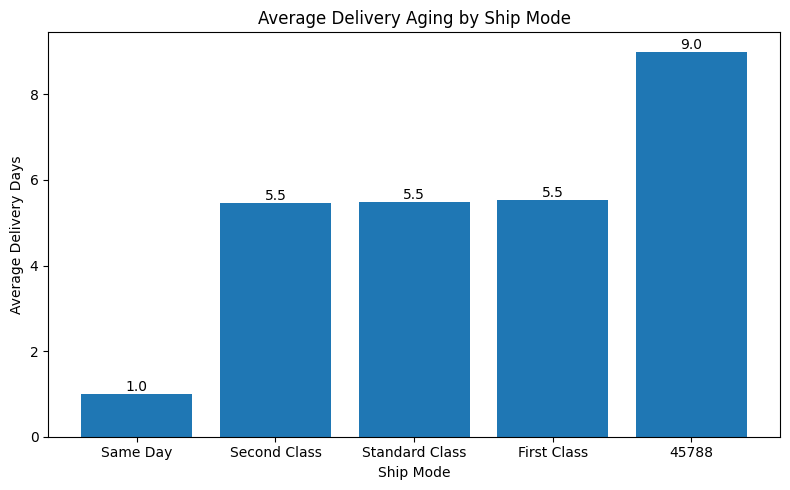

In [4]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    aging_analysis.index,
    aging_analysis["Average_Aging"]
)

plt.title("Average Delivery Aging by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Delivery Days")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../charts/average_delivery_aging.png", dpi=300)

plt.show()

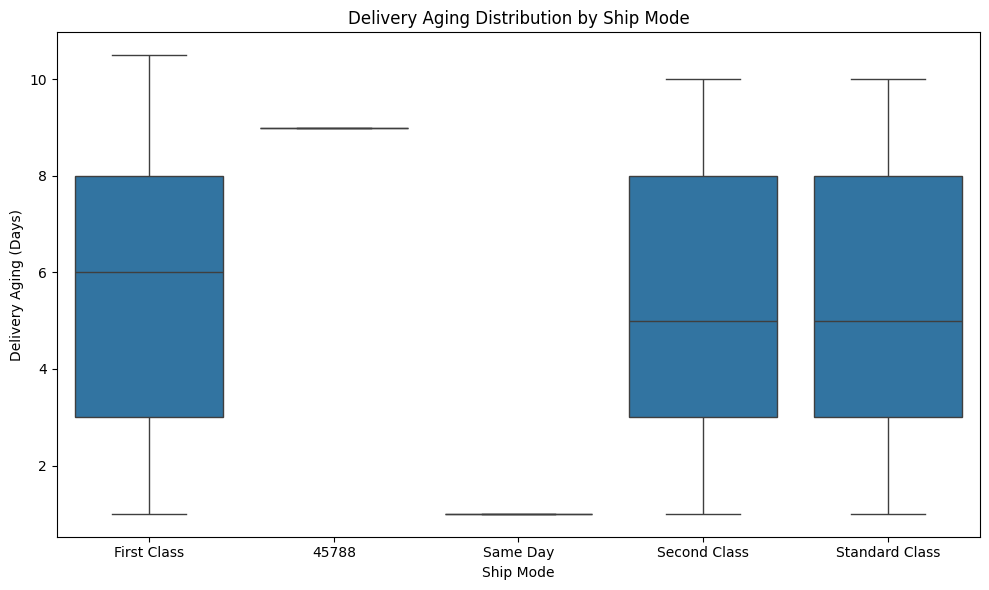

In [5]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Ship Mode",
    y="Aging"
)

plt.title("Delivery Aging Distribution by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Delivery Aging (Days)")

plt.tight_layout()

plt.savefig("../charts/delivery_aging_boxplot.png", dpi=300)

plt.show()

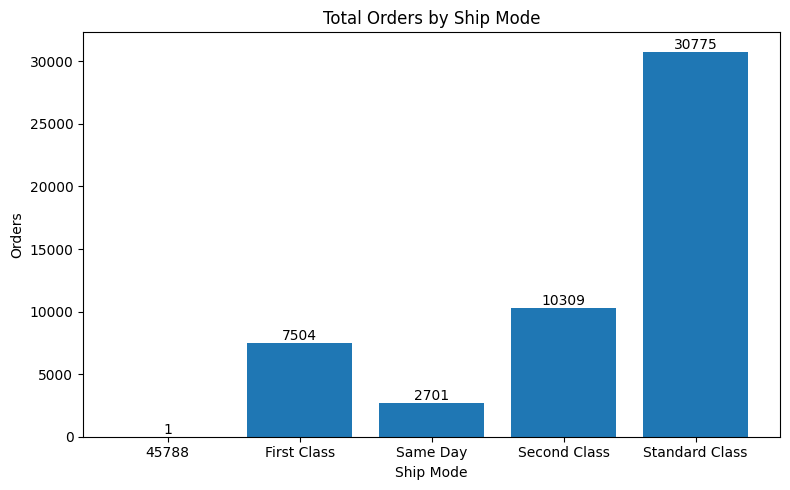

In [6]:
orders = (
    df.groupby("Ship Mode")["Order ID"]
      .nunique()
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    orders.index,
    orders.values
)

plt.title("Total Orders by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Orders")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig("../charts/orders_by_shipmode.png", dpi=300)

plt.show()

In [7]:
aging_summary = df["Aging"].describe()

aging_summary

count    51289.000000
mean         5.255035
std          2.959948
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         10.500000
Name: Aging, dtype: float64

## Business Insights

- Calculated the average, minimum, and maximum delivery aging for each shipping mode.
- Identified the fastest and slowest shipping methods.
- Compared the number of orders handled by each shipping mode.
- Analyzed the spread of delivery times using a boxplot.

### Recommendations

- Promote the fastest shipping mode for time-sensitive orders.
- Investigate causes of delays in slower shipping methods.
- Optimize logistics processes to reduce delivery aging and improve customer satisfaction.